In [1]:
import pandas as pd
import numpy as np

In [2]:
CSV_A = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_cellposeSAM_beforeREDSEA_gnn_predict.csv"
CSV_B = "/mnt/jwh83-data/Confetti/output/Redsea/Clustering/20260119_ns444_cellposeSAM_afterREDSEA_gnn_predict.csv"

CLUSTER_COL = "leiden"
CELLTYPE_COL = "pred_name"
SLIDE_COL = "slide_name"   


FORCE_STRING_IDS = True

In [3]:
CLUSTER = "leiden"
CTYPE   = "pred_name"
SLIDE   = "slide_name"
CELLID  = "CellID"
XCOL    = "x_centroid"
YCOL    = "y_centroid"

In [4]:
def load_minimal(csv_path):
    df = pd.read_csv(csv_path)

    keep = [SLIDE, CELLID, CLUSTER, CTYPE]
    # coords optional for diagnostics / fallback matching
    for c in [XCOL, YCOL]:
        if c in df.columns:
            keep.append(c)

    missing = [c for c in [SLIDE, CELLID, CLUSTER, CTYPE] if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_path} missing required columns: {missing}")

    df = df[keep].copy()
    df = df.dropna(subset=[SLIDE, CELLID, CLUSTER, CTYPE])

    # Normalize datatypes
    df[SLIDE] = df[SLIDE].astype(str)
    df[CELLID] = df[CELLID].astype(str)
    df[CLUSTER] = df[CLUSTER].astype(str)
    df[CTYPE] = df[CTYPE].astype(str)

    return df

A = load_minimal(CSV_A)
B = load_minimal(CSV_B)

# If CellID is only unique within slide, join on both.
merged = A.merge(
    B,
    on=[SLIDE, CELLID],
    how="inner",
    suffixes=("_A", "_B")
)

print("A cells:", len(A))
print("B cells:", len(B))
print("Matched cells (inner join):", len(merged))
print("Match rate A:", len(merged) / len(A))
print("Match rate B:", len(merged) / len(B))

# Quick sanity checks
dupsA = A.duplicated(subset=[SLIDE, CELLID]).sum()
dupsB = B.duplicated(subset=[SLIDE, CELLID]).sum()
print("Duplicate (slide, CellID) in A:", dupsA)
print("Duplicate (slide, CellID) in B:", dupsB)

A cells: 173783
B cells: 172465
Matched cells (inner join): 172169
Match rate A: 0.9907125553132354
Match rate B: 0.9982837097382078
Duplicate (slide, CellID) in A: 0
Duplicate (slide, CellID) in B: 0


In [5]:
def cluster_purity_table_from_series(cluster_s, ctype_s):
    df = pd.DataFrame({"cluster": cluster_s.astype(str), "ctype": ctype_s.astype(str)})
    # counts per cluster x celltype
    ct = df.groupby(["cluster", "ctype"]).size().rename("count").reset_index()
    totals = ct.groupby("cluster")["count"].sum().rename("n_cells").reset_index()

    ct_sorted = ct.sort_values(["cluster", "count"], ascending=[True, False])
    top = (ct_sorted.groupby("cluster").head(1)
           .rename(columns={"ctype":"top_celltype", "count":"top_count"})[["cluster","top_celltype","top_count"]])

    n_types = ct.groupby("cluster")["ctype"].nunique().rename("n_celltypes").reset_index()

    # entropy
    ct2 = ct.merge(totals, on="cluster", how="left")
    ct2["p"] = ct2["count"] / ct2["n_cells"]
    ent = (ct2.assign(term=lambda x: np.where(x["p"] > 0, -x["p"] * np.log2(x["p"]), 0.0))
                .groupby("cluster")["term"].sum().rename("entropy").reset_index())

    out = totals.merge(top, on="cluster").merge(n_types, on="cluster").merge(ent, on="cluster")
    out["purity"] = out["top_count"] / out["n_cells"]
    out = out.sort_values(["purity","n_cells"], ascending=[False, False]).reset_index(drop=True)
    return out

purA = cluster_purity_table_from_series(merged[f"{CLUSTER}_A"], merged[f"{CTYPE}_A"])
purB = cluster_purity_table_from_series(merged[f"{CLUSTER}_B"], merged[f"{CTYPE}_B"])

overallA = purA["top_count"].sum() / purA["n_cells"].sum()
overallB = purB["top_count"].sum() / purB["n_cells"].sum()

print(f"Overall weighted purity (matched cells only): A={overallA:.4f}, B={overallB:.4f}, A-B={overallA-overallB:.4f}")

display(purA.head(20))
display(purB.head(20))

Overall weighted purity (matched cells only): A=0.6479, B=0.6355, A-B=0.0124


,cluster,n_cells,top_celltype,top_count,n_celltypes,entropy,purity
0,36,2013,Smooth muscle,2008,3,0.026865,0.997516
1,39,375,B,373,3,0.053278,0.994667
2,35,1106,Paneth,1090,9,0.150478,0.985533
3,30,1762,Smooth muscle,1722,5,0.194803,0.977299
4,15,5580,Smooth muscle,5397,11,0.288361,0.967204
5,29,6671,Plasma,6269,13,0.455928,0.939739
6,22,2064,M2 Macrophage,1876,8,0.609993,0.908915
7,9,4617,Nerve,4026,15,0.816905,0.871995
8,23,6782,Epithelial,5908,13,0.799146,0.871129
9,18,5953,CD4+ T,4971,14,1.036403,0.835041


,cluster,n_cells,top_celltype,top_count,n_celltypes,entropy,purity
0,32,385,B,383,3,0.052092,0.994805
1,19,3612,Smooth muscle,3415,13,0.409422,0.945460
2,25,1472,Paneth,1364,12,0.576062,0.926630
3,10,7694,Smooth muscle,7018,14,0.669084,0.912139
4,30,7827,Plasma,7065,16,0.732659,0.902645
5,8,6153,M2 Macrophage,5408,19,0.882152,0.878921
6,14,4750,Nerve,4163,18,0.907192,0.876421
7,7,5700,Plasma,4788,21,1.110557,0.840000
8,20,5281,CD4+ T,4395,19,1.053380,0.832229
9,29,4619,CD66+ Epithelial,3831,17,1.069351,0.829400


In [6]:
def composition_matrix(cluster_s, ctype_s):
    tab = pd.crosstab(cluster_s.astype(str), ctype_s.astype(str))
    frac = tab.div(tab.sum(axis=1), axis=0)
    return tab, frac

countsA, fracA = composition_matrix(merged[f"{CLUSTER}_A"], merged[f"{CTYPE}_A"])
countsB, fracB = composition_matrix(merged[f"{CLUSTER}_B"], merged[f"{CTYPE}_B"])

# Ensure same columns (cell types) for similarity computations
all_types = sorted(set(fracA.columns) | set(fracB.columns))
fracA = fracA.reindex(columns=all_types, fill_value=0.0)
fracB = fracB.reindex(columns=all_types, fill_value=0.0)

print("Clusters A:", fracA.shape[0], " | Clusters B:", fracB.shape[0], " | Cell types:", len(all_types))

Clusters A: 40  | Clusters B: 33  | Cell types: 28


In [7]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment

sim = cosine_similarity(fracA.values, fracB.values)  # (nA x nB), higher = more similar

# Hungarian solves a MIN cost assignment; use cost = 1 - similarity
cost = 1.0 - sim
row_ind, col_ind = linear_sum_assignment(cost)

match_df = pd.DataFrame({
    "cluster_A": fracA.index[row_ind],
    "cluster_B": fracB.index[col_ind],
    "cosine_similarity": sim[row_ind, col_ind],
})

# Add purities for each matched cluster
purA_map = purA.set_index("cluster")[["n_cells","top_celltype","purity","entropy","n_celltypes"]].add_suffix("_A")
purB_map = purB.set_index("cluster")[["n_cells","top_celltype","purity","entropy","n_celltypes"]].add_suffix("_B")

match_df = (match_df
            .join(purA_map, on="cluster_A")
            .join(purB_map, on="cluster_B"))

match_df["purity_diff_A_minus_B"] = match_df["purity_A"] - match_df["purity_B"]
match_df = match_df.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)

display(match_df.head(30))

,cluster_A,cluster_B,cosine_similarity,n_cells_A,top_celltype_A,purity_A,entropy_A,n_celltypes_A,n_cells_B,top_celltype_B,purity_B,entropy_B,n_celltypes_B,purity_diff_A_minus_B
0,39,32,1.000000,375,B,0.994667,0.053278,3,385,B,0.994805,0.052092,3,-0.000139
1,17,16,0.999861,1446,Neuroendocrine,0.825726,1.161919,18,1566,Neuroendocrine,0.808429,1.286167,20,0.017297
2,18,20,0.999860,5953,CD4+ T,0.835041,1.036403,14,5281,CD4+ T,0.832229,1.053380,19,0.002812
3,20,29,0.999803,4857,CD66+ Epithelial,0.825818,1.088482,17,4619,CD66+ Epithelial,0.829400,1.069351,17,-0.003582
4,29,30,0.999731,6671,Plasma,0.939739,0.455928,13,7827,Plasma,0.902645,0.732659,16,0.037094
5,30,19,0.999729,1762,Smooth muscle,0.977299,0.194803,5,3612,Smooth muscle,0.945460,0.409422,13,0.031839
6,15,10,0.999611,5580,Smooth muscle,0.967204,0.288361,11,7694,Smooth muscle,0.912139,0.669084,14,0.055065
7,22,8,0.999512,2064,M2 Macrophage,0.908915,0.609993,8,6153,M2 Macrophage,0.878921,0.882152,19,0.029994
8,35,25,0.999426,1106,Paneth,0.985533,0.150478,9,1472,Paneth,0.926630,0.576062,12,0.058903
9,25,15,0.999363,1081,PDPN+ Stromal,0.834413,1.015001,11,1313,PDPN+ Stromal,0.824829,1.156572,15,0.009584


In [8]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

leiden_A = merged[f"{CLUSTER}_A"].astype(str).values
leiden_B = merged[f"{CLUSTER}_B"].astype(str).values

ari = adjusted_rand_score(leiden_A, leiden_B)
nmi = normalized_mutual_info_score(leiden_A, leiden_B)

print(f"Leiden agreement on matched cells: ARI={ari:.4f} | NMI={nmi:.4f}")

Leiden agreement on matched cells: ARI=0.4706 | NMI=0.6331


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
def _prep_purity_df(pur_tbl: pd.DataFrame, label: str) -> pd.DataFrame:
    d = pur_tbl.copy()
    d["dataset"] = label
    d["cluster"] = d["cluster"].astype(str)
    d["purity"] = d["purity"].astype(float)
    d["n_cells"] = d["n_cells"].astype(float)
    # keep a stable ordering: by cluster id (string) then n_cells
    return d[["dataset", "cluster", "purity", "n_cells", "top_celltype"]]

purA_plot = _prep_purity_df(purA, "A")
purB_plot = _prep_purity_df(purB, "B")


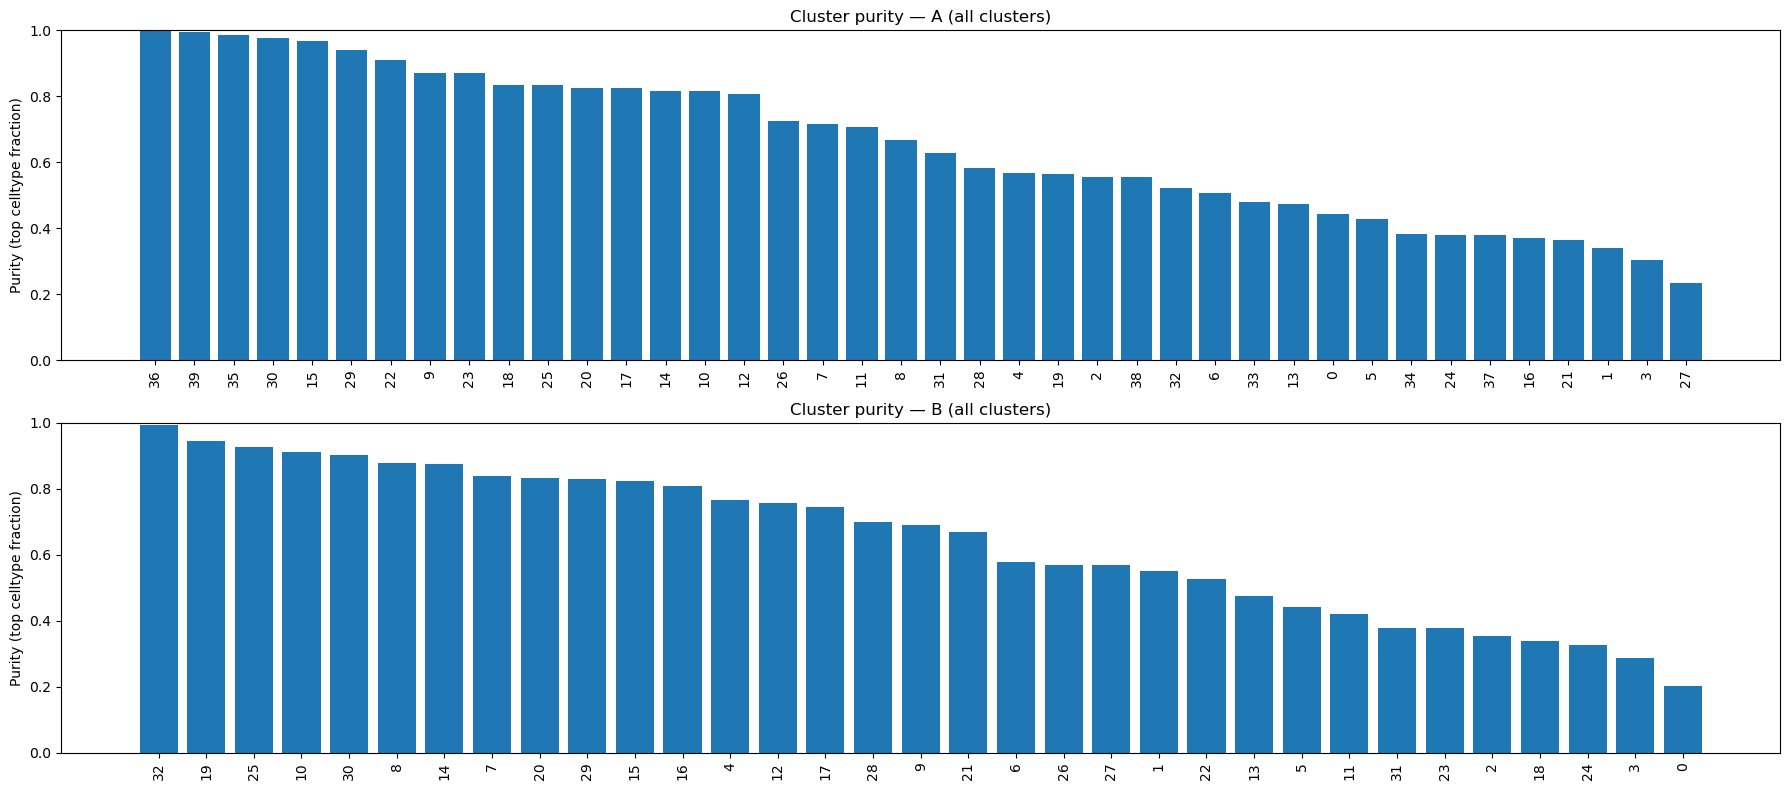

In [11]:
purA_plot_s = purA_plot.sort_values(["purity","n_cells"], ascending=[False, False]).reset_index(drop=True)
purB_plot_s = purB_plot.sort_values(["purity","n_cells"], ascending=[False, False]).reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(max(10, 0.45*max(len(purA_plot_s), len(purB_plot_s))), 8), sharey=True)

# A
ax = axes[0]
ax.bar(purA_plot_s["cluster"].astype(str).values, purA_plot_s["purity"].values)
ax.set_title("Cluster purity — A (all clusters)")
ax.set_ylabel("Purity (top celltype fraction)")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", labelrotation=90)

# B
ax = axes[1]
ax.bar(purB_plot_s["cluster"].astype(str).values, purB_plot_s["purity"].values)
ax.set_title("Cluster purity — B (all clusters)")
ax.set_ylabel("Purity (top celltype fraction)")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", labelrotation=90)

plt.tight_layout()
plt.show()

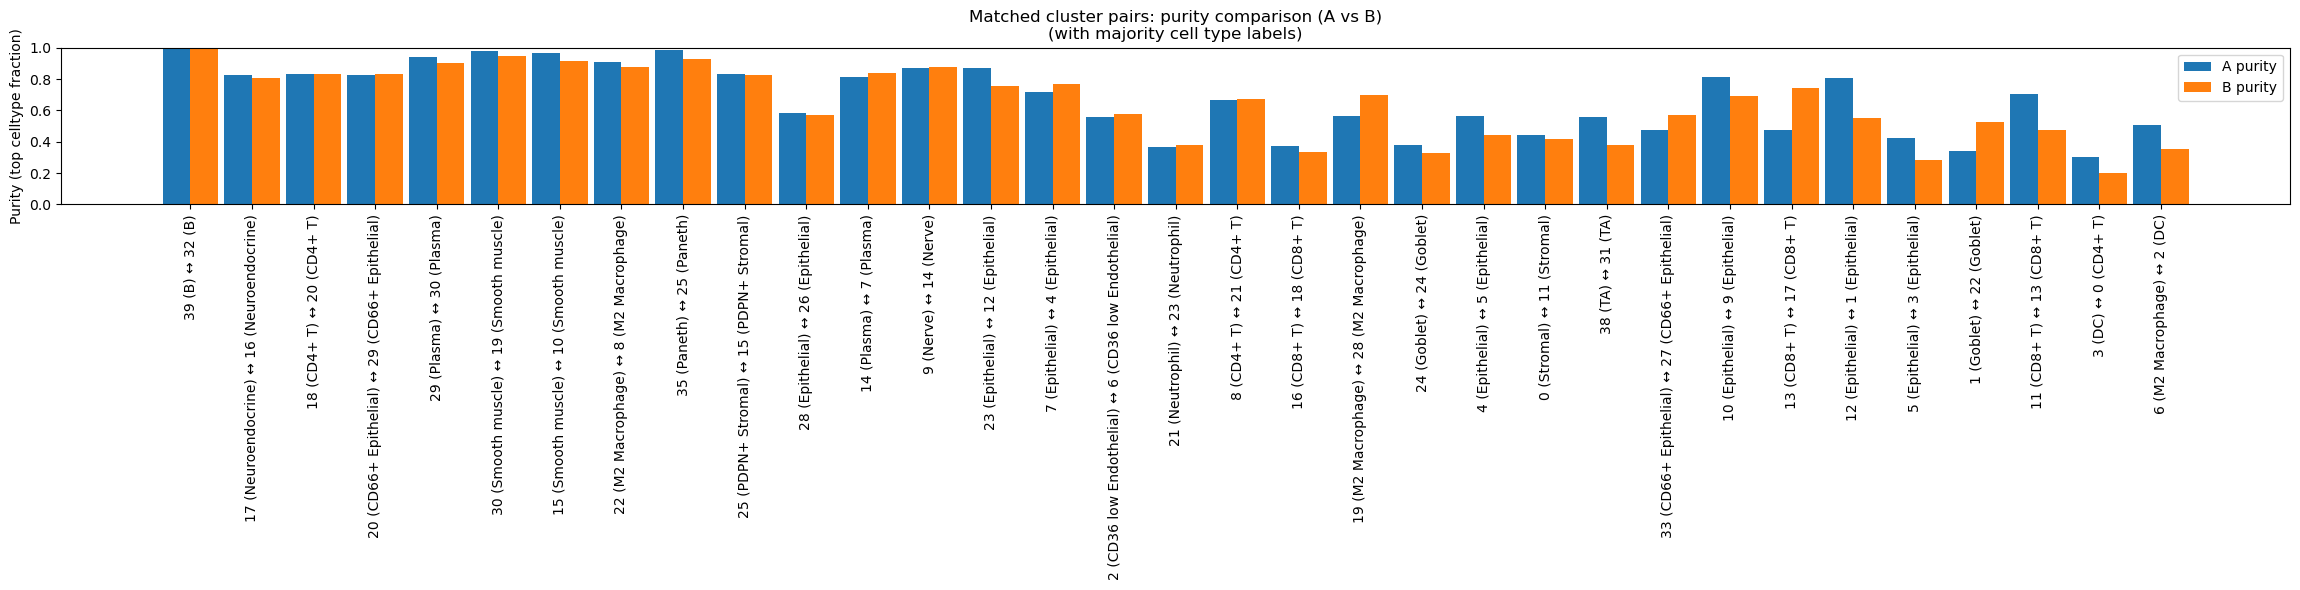

In [13]:
pairs = match_df.copy()
pairs["cluster_A"] = pairs["cluster_A"].astype(str)
pairs["cluster_B"] = pairs["cluster_B"].astype(str)

# Build a richer label:
# clusterA (top_type_A) ↔ clusterB (top_type_B)
pairs["pair"] = (
    pairs["cluster_A"] + " (" + pairs["top_celltype_A"].astype(str) + ")"
    + " ↔ " +
    pairs["cluster_B"] + " (" + pairs["top_celltype_B"].astype(str) + ")"
)

# Choose ordering: best cosine similarity first
pairs = pairs.sort_values("cosine_similarity", ascending=False).reset_index(drop=True)

# Build side-by-side bars
x = np.arange(len(pairs))
width = 0.45

fig, ax = plt.subplots(figsize=(max(12, 0.7 * len(pairs)), 6))
ax.bar(x - width/2, pairs["purity_A"].values, width, label="A purity")
ax.bar(x + width/2, pairs["purity_B"].values, width, label="B purity")

ax.set_title("Matched cluster pairs: purity comparison (A vs B)\n(with majority cell type labels)")
ax.set_ylabel("Purity (top celltype fraction)")
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(pairs["pair"].values, rotation=90, ha="center")
ax.legend()

plt.tight_layout()
plt.show()

,pair,cluster_A,top_celltype_A,n_cells_A,purity_A,cluster_B,top_celltype_B,n_cells_B,purity_B,purity_improvement_B_minus_A,cosine_similarity
0,13 (CD8+ T) ↔ 17 (CD8+ T),13,CD8+ T,4802,0.474594,17,CD8+ T,6155,0.743948,0.269354,0.949683
1,1 (Goblet) ↔ 22 (Goblet),1,Goblet,9493,0.338460,22,Goblet,6638,0.526363,0.187903,0.907816
2,19 (M2 Macrophage) ↔ 28 (M2 Macrophage),19,M2 Macrophage,4912,0.565554,28,M2 Macrophage,2780,0.699281,0.133727,0.987999
3,33 (CD66+ Epithelial) ↔ 27 (CD66+ Epithelial),33,CD66+ Epithelial,4770,0.477987,27,CD66+ Epithelial,3247,0.569141,0.091153,0.966466
4,7 (Epithelial) ↔ 4 (Epithelial),7,Epithelial,4139,0.715632,4,Epithelial,13325,0.766154,0.050522,0.993855
5,14 (Plasma) ↔ 7 (Plasma),14,Plasma,5930,0.815852,7,Plasma,5700,0.840000,0.024148,0.998694
6,2 (CD36 low Endothelial) ↔ 6 (CD36 low Endothe...,2,CD36 low Endothelial,8014,0.556651,6,CD36 low Endothelial,11051,0.576690,0.020039,0.993606
7,21 (Neutrophil) ↔ 23 (Neutrophil),21,Neutrophil,1567,0.365029,23,Neutrophil,1541,0.377028,0.011999,0.993578
8,9 (Nerve) ↔ 14 (Nerve),9,Nerve,4617,0.871995,14,Nerve,4750,0.876421,0.004426,0.997396
9,8 (CD4+ T) ↔ 21 (CD4+ T),8,CD4+ T,5723,0.665909,21,CD4+ T,6245,0.669976,0.004066,0.991158


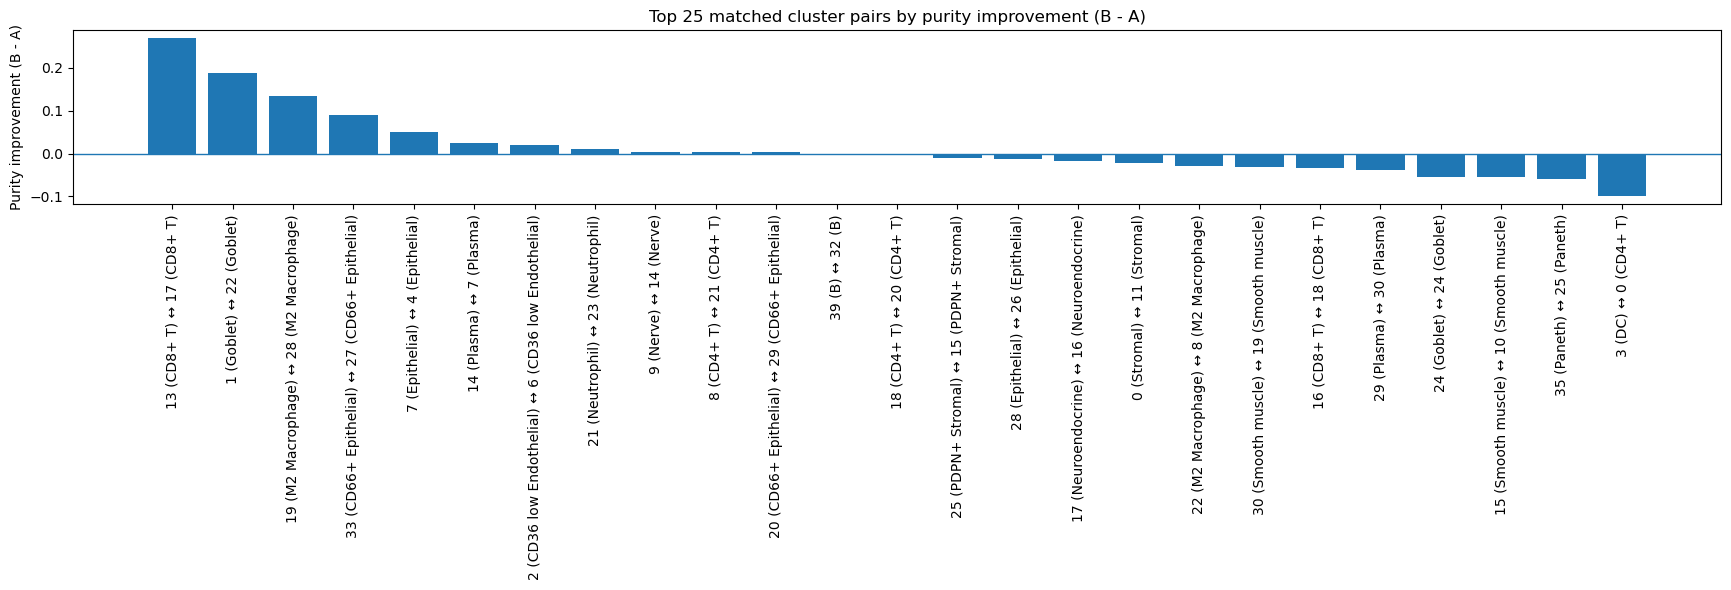

In [14]:
improve = match_df.copy()

# Ensure numeric
improve["purity_A"] = pd.to_numeric(improve["purity_A"], errors="coerce")
improve["purity_B"] = pd.to_numeric(improve["purity_B"], errors="coerce")

# Improvement = B - A (positive means improved after)
improve["purity_improvement_B_minus_A"] = improve["purity_B"] - improve["purity_A"]

# Nice label
improve["pair"] = (
    improve["cluster_A"].astype(str) + " (" + improve["top_celltype_A"].astype(str) + ")"
    + " ↔ " +
    improve["cluster_B"].astype(str) + " (" + improve["top_celltype_B"].astype(str) + ")"
)

# Order by biggest improvement (then similarity, then n_cells_B)
improve = improve.sort_values(
    ["purity_improvement_B_minus_A", "cosine_similarity", "n_cells_B"],
    ascending=[False, False, False],
).reset_index(drop=True)

cols = [
    "pair",
    "cluster_A", "top_celltype_A", "n_cells_A", "purity_A",
    "cluster_B", "top_celltype_B", "n_cells_B", "purity_B",
    "purity_improvement_B_minus_A",
    "cosine_similarity",
]
display(improve[cols].head(30))

# Optional: bar plot of top improvements
topk = 25 if len(improve) > 25 else len(improve)
plot_df = improve.head(topk)

import matplotlib.pyplot as plt

x = np.arange(topk)
fig, ax = plt.subplots(figsize=(max(12, 0.7*topk), 6))
ax.bar(x, plot_df["purity_improvement_B_minus_A"].values)

ax.axhline(0, linewidth=1)
ax.set_title(f"Top {topk} matched cluster pairs by purity improvement (B - A)")
ax.set_ylabel("Purity improvement (B - A)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["pair"].values, rotation=90)

plt.tight_layout()
plt.show()